#Importing libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = sns.load_dataset('titanic')

# Imputaion and Removing Values

In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
df = df.drop('deck' , axis = 1)

In [ ]:
df["age"] = df["age"].fillna(df["age"].median())
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


#Visualing the data

<Axes: xlabel='sex', ylabel='count'>

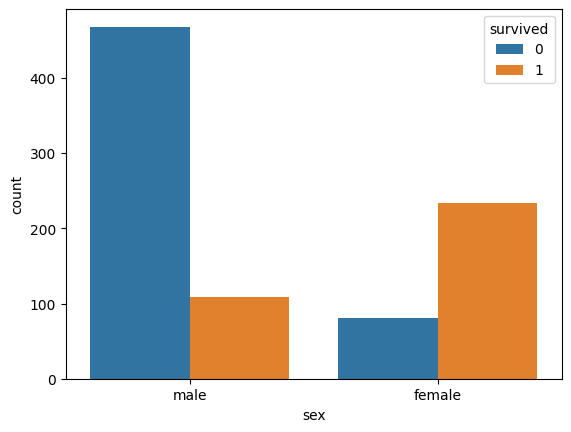

In [ ]:
# Can your sex predict your survival
sns.countplot(x = 'sex' , data = df , hue = 'survived')

<Axes: xlabel='pclass', ylabel='count'>

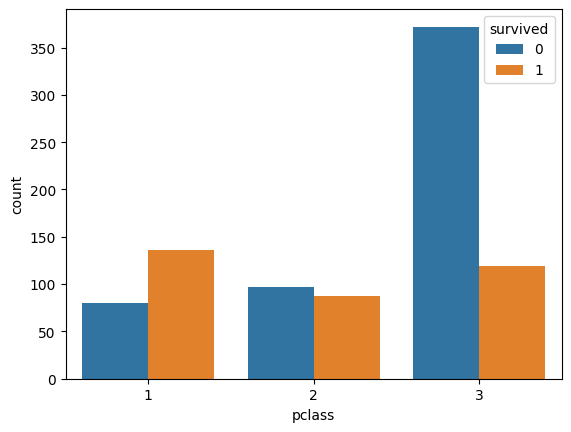

In [ ]:
# Does your survival probability depend on your class?
sns.countplot(x = 'pclass' , data = df, hue = "survived")

<Axes: xlabel='age', ylabel='Count'>

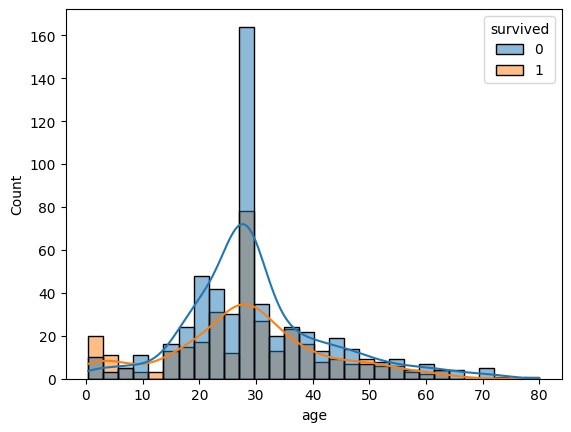

In [ ]:
# Relation of Survival with age
sns.histplot(x = "age" , data = df , hue = "survived" , bins= 30 , kde = True)

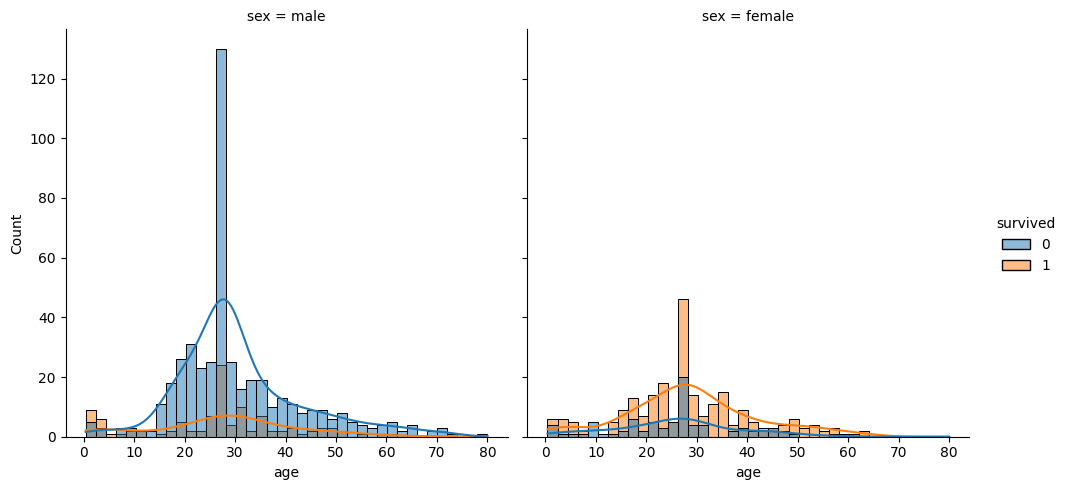

In [ ]:
sns.displot(data=df,x="age",hue="survived",col="sex",bins=40,kde=True)


# Training the Model


In [ ]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')

In [ ]:
X = df[["pclass" , "sex" , "age" , "sibsp" , "parch" , "fare" , "embarked"]].copy()
Y = df["survived"]

In [ ]:
X["sex"] = X["sex"].map({"male" : 0 , "female" : 1})
X["embarked_C"] = (X["embarked"] == "C").astype(int)
X["embarked_Q"] = (X["embarked"] == "Q").astype(int)
X = X.drop("embarked" , axis = 1)
print(X.isnull().sum())
print(X.head())

pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked_C    0
embarked_Q    0
dtype: int64
   pclass  sex   age  sibsp  parch     fare  embarked_C  embarked_Q
0       3    0  22.0      1      0   7.2500           0           0
1       1    1  38.0      1      0  71.2833           1           0
2       3    1  26.0      0      0   7.9250           0           0
3       1    1  35.0      1      0  53.1000           0           0
4       3    0  35.0      0      0   8.0500           0           0


#Adding features to improve our Results

In [ ]:
X["sex_age"] = X["sex"] * X["age"]
X["is_child"] = (X["age"] < 10).astype(int)

#Shuffling and Splitting the Dataset

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test , Y_train ,Y_test = train_test_split(X , Y , test_size = 0.2 , random_state = 42, shuffle = True)

#Scaling the Dataset

In [ ]:
# for col in ['pclass','age', 'sibsp', 'parch', 'fare' , 'sex_age' , 'is_boy_child' , 'is_girl_child']:
#     mean = X_train[col].mean()
#     std = X_train[col].std()
#     X_train[col] =  ( X_train[col] - mean ) / std
#     X_test[col] = ( X_test[col] - mean) / std

for col in ['pclass','age', 'sibsp', 'parch', 'fare' , 'sex_age' , "is_child"]:
    mean = X_train[col].mean()
    std = X_train[col].std()
    X_train[col] =  ( X_train[col] - mean ) / std
    X_test[col] = ( X_test[col] - mean) / std

# for col in ['pclass','age', 'sibsp', 'parch', 'fare']:
#     mean = X_train[col].mean()
#     std = X_train[col].std()
#     X_train[col] =  ( X_train[col] - mean ) / std
#     X_test[col] = ( X_test[col] - mean) / std



#Adding the Bais

In [ ]:
X_train["bias"] = 1
X_test["bias"] = 1

In [ ]:
X_train_np = np.array(X_train)
X_test_np = np.array(X_test)
Y_train_np = np.array(Y_train)
Y_test_np = np.array(Y_test)

In [ ]:
def sigmoid(z):
  return 1/(1 + np.exp(-z))

In [ ]:
def log_loss(y , y_hat):
  eps = 1e-15
  y_hat = np.clip(y_hat ,eps, 1 - eps)
  return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

In [ ]:
def gradient(X , y , w):
  y_hat = sigmoid(X @ w);
  n = X.shape[0]
  return (X.T @ (y_hat - y))/n


In [ ]:
w = np.zeros(X_train_np.shape[1])
learning_rate = 0.1
epochs = 1000

for epoch in range(epochs):
  y_hat = sigmoid(X_train_np @ w);
  loss = log_loss(Y_train_np , y_hat);
  grad = gradient(X_train_np, Y_train_np , w);

  w = w - learning_rate * grad;

  if (epoch % 25 == 0):
    print(f"Epoch {epoch} , Loss is {loss}")


Epoch 0 , Loss is 0.6931471805599453
Epoch 25 , Loss is 0.5273710390361904
Epoch 50 , Loss is 0.4771291044818111
Epoch 75 , Loss is 0.4546591742746456
Epoch 100 , Loss is 0.4426455129618898
Epoch 125 , Loss is 0.43554159579094853
Epoch 150 , Loss is 0.43105596505594196
Epoch 175 , Loss is 0.4280866685332047
Epoch 200 , Loss is 0.4260480297631969
Epoch 225 , Loss is 0.42460593275154845
Epoch 250 , Loss is 0.4235594486053372
Epoch 275 , Loss is 0.4227827065526585
Epoch 300 , Loss is 0.4221942399159237
Epoch 325 , Loss is 0.4217398899923618
Epoch 350 , Loss is 0.42138283225690293
Epoch 375 , Loss is 0.4210975389443972
Epoch 400 , Loss is 0.4208660103155433
Epoch 425 , Loss is 0.42067536018131807
Epoch 450 , Loss is 0.42051623428283313
Epoch 475 , Loss is 0.42038175412916756
Epoch 500 , Loss is 0.4202667997720645
Epoch 525 , Loss is 0.42016751547231157
Epoch 550 , Loss is 0.42008096445852705
Epoch 575 , Loss is 0.4200048849286129
Epoch 600 , Loss is 0.4199375157319974
Epoch 625 , Loss is 0

In [ ]:
y_test_hat = sigmoid(X_test_np @ w);
y_test_pred = (y_test_hat >= 0.5).astype(int)

accuracy = np.mean(y_test_pred == Y_test_np)
print(f"The Accuracy is {accuracy}")

The Accuracy is 0.7932960893854749


In [ ]:
w

array([-0.7288741 ,  0.52084911, -0.38331494, -0.54912806, -0.30489641,
        0.21371349,  0.46339608,  0.10124077,  1.35773167,  0.68118772,
       -0.91311308])